# Terrain and hydrology, in memory

Hillshade, D8 flow accumulation and watershed delineation on the Whitebox Next Gen engine (open tier, MIT/Apache-2.0) — rasters stay in memory, no CLI round-trips.

Requires the extras: `pip install mapsmith[raster,whitebox]`.

In [1]:
import base64
from pathlib import Path

import numpy as np
import rasterio
from rasterio.transform import from_origin

data = Path('data'); data.mkdir(exist_ok=True)

# synthetic 160x160 DEM (30 m cells): two superposed hill wavelengths over a
# broad valley descending south. Analytic, so every run is bit-identical.
x, y = np.meshgrid(np.arange(160, dtype='float32'),
                   np.arange(160, dtype='float32'))
elevation = (
    22 * np.sin(x / 9) * np.cos(y / 11)             # main hills
    + 11 * np.sin(x / 23 + 1.3) * np.cos(y / 7 + 0.7)  # secondary relief
    + 0.006 * (x - 80) ** 2                         # valley walls, lowest at x=80
    + 0.9 * (159 - y)                               # gentle southward slope
).astype('float32')
dem_path = data / 'dem.tif'
with rasterio.open(dem_path, 'w', driver='GTiff', height=160, width=160,
                   count=1, dtype='float32', crs='EPSG:32632',
                   transform=from_origin(500000, 5000000, 30, 30),
                   nodata=-32768.0) as dst:
    dst.write(elevation, 1)
print('DEM written:', dem_path)

DEM written: data\dem.tif


## Hillshade

In [2]:
from mapsmith.engines import whitebox_engine

hs = whitebox_engine.hillshade(str(dem_path), str(data / 'hillshade.tif'),
                               azimuth=315, altitude=35)
hs

{'output': 'data\\hillshade.tif',
 'azimuth': 315,
 'altitude': 35,
 'provenance': 'data\\hillshade.tif.provenance.json',
 'verified': True}

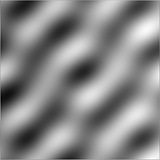

In [3]:
from IPython.display import Image
from mapsmith import preview

png = preview.raster_preview(str(data / 'hillshade.tif'))
Image(data=base64.b64decode(png['png_data_uri'].split(',', 1)[1]), width=360)

## Flow accumulation and watershed

In [4]:
# log_transform: raw D8 counts are 1 almost everywhere and huge on the
# channel — the log view is how you actually see a drainage network
acc = whitebox_engine.flow_accumulation(str(dem_path), str(data / 'flowacc.tif'),
                                        log_transform=True)
acc

{'output': 'data\\flowacc.tif',
 'method': 'd8',
 'out_type': 'cells',
 'provenance': 'data\\flowacc.tif.provenance.json',
 'verified': True}

In [5]:
import geopandas as gpd
from shapely.geometry import Point

# snap the outlet onto the stream: the highest-accumulation cell one row
# above the southern edge is where the main channel leaves the grid
with rasterio.open(data / 'flowacc.tif') as src:
    grid = src.read(1)
    row = grid.shape[0] - 2
    col = int(np.argmax(grid[row]))
    outlet_xy = src.xy(row, col)

outlet = gpd.GeoDataFrame({'id': [1]}, geometry=[Point(*outlet_xy)],
                          crs='EPSG:32632')
outlet.to_file(data / 'outlet.gpkg')
ws = whitebox_engine.watershed(str(dem_path), str(data / 'outlet.gpkg'),
                               str(data / 'basin.tif'))
ws

{'output': 'data\\basin.tif',
 'n_pour_points': 1,
 'provenance': 'data\\basin.tif.provenance.json',
 'verified': True}

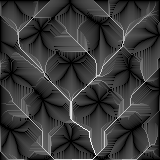

In [6]:
png = preview.raster_preview(str(data / 'flowacc.tif'))
Image(data=base64.b64decode(png['png_data_uri'].split(',', 1)[1]), width=360)

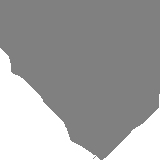

In [7]:
# the delineated catchment: basin cells in gray, everything else transparent
png = preview.raster_preview(str(data / 'basin.tif'))
Image(data=base64.b64decode(png['png_data_uri'].split(',', 1)[1]), width=360)

## Zonal statistics on the DEM

exactextract computes statistics with exact fractional pixel coverage (no all-in/all-out approximation).

In [8]:
from shapely.geometry import box
from mapsmith.engines import raster

zones = gpd.GeoDataFrame(
    {'side': ['west', 'east']},
    geometry=[box(500000, 5000000 - 4800, 500000 + 2400, 5000000),
              box(500000 + 2400, 5000000 - 4800, 500000 + 4800, 5000000)],
    crs='EPSG:32632')
zones.to_parquet(data / 'zones.parquet')
stats = raster.zonal_statistics(str(dem_path), str(data / 'zones.parquet'),
                                str(data / 'zone_elevation.parquet'),
                                ['mean', 'min', 'max'])
gpd.read_parquet(data / 'zone_elevation.parquet')[['side', 'mean', 'min', 'max']]

,side,mean,min,max
0,west,84.842668,-4.854171,200.575775
1,east,83.809499,-1.890810,184.308151


Every raster above has its own provenance manifest and deterministic checks on disk.